In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Connect to SQLite
DB_PATH = Path("data/processed/munich_airbnb.db")
conn = sqlite3.connect(DB_PATH)

print("✅ Connected to database!")

✅ Connected to database!


KPI SUMMARY

In [2]:
kpis = pd.read_sql("""
    SELECT
        COUNT(*)                              AS total_listings,
        ROUND(AVG(price), 2)                  AS avg_price_per_night,
        ROUND(MIN(price), 2)                  AS min_price,
        ROUND(MAX(price), 2)                  AS max_price,
        ROUND(AVG(review_scores_rating), 2)   AS avg_review_score,
        COUNT(DISTINCT neighbourhood_cleansed) AS total_neighbourhoods
    FROM listings
""", conn)

print("=" * 50)
print("  MUNICH VACATION RENTAL — KPI SUMMARY")
print("=" * 50)
print(kpis.T.to_string(header=False))
print("=" * 50)

  MUNICH VACATION RENTAL — KPI SUMMARY
total_listings        5487.00
avg_price_per_night    238.84
min_price               41.00
max_price             1229.00
avg_review_score         4.81
total_neighbourhoods    25.00


Average Price by Neighberhood

                                         neighbourhood  total_listings  avg_price  min_price  max_price
                                        Altstadt-Lehel             208     390.66       45.0     1225.0
                          Ludwigsvorstadt-Isarvorstadt             639     351.97       43.0     1229.0
                                      Schwanthalerhöhe             184     308.99       45.0     1185.0
                                           Maxvorstadt             428     286.09       46.0     1203.0
                                         Au-Haidhausen             292     250.35       45.0     1149.0
                                              Sendling             178     242.44       45.0     1200.0
                                 Neuhausen-Nymphenburg             304     224.33       42.0     1064.0
                                        Schwabing-West             347     216.13       42.0     1100.0
                                    Schwabing-Freimann          

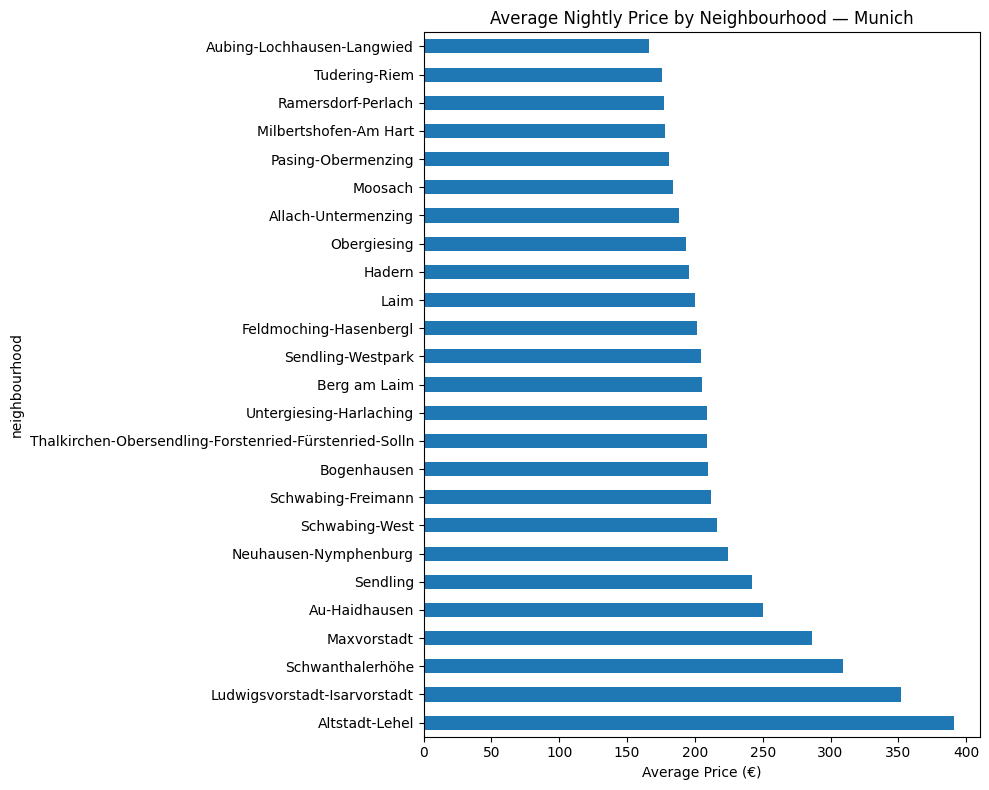

In [5]:
neighbourhood_price = pd.read_sql("""
    SELECT
        neighbourhood_cleansed        AS neighbourhood,
        COUNT(*)                      AS total_listings,
        ROUND(AVG(price), 2)          AS avg_price,
        ROUND(MIN(price), 2)          AS min_price,
        ROUND(MAX(price), 2)          AS max_price
    FROM listings
    GROUP BY neighbourhood_cleansed
    ORDER BY avg_price DESC
""", conn)

print(neighbourhood_price.to_string(index=False))

neighbourhood_price.plot(
    kind="barh",
    x="neighbourhood",
    y="avg_price",
    figsize=(10, 8),
    legend=False,
    title="Average Nightly Price by Neighbourhood — Munich"
)

plt.xlabel("Average Price (€)")
plt.tight_layout()
plt.savefig("outputs/avg_price_by_neighbourhood.png", dpi=150)
plt.show()

Rooms Analysis

      room_type  total_listings  avg_price
Entire home/apt            3663     280.41
   Private room            1790     155.67
    Shared room              22     109.45
     Hotel room              12     194.42


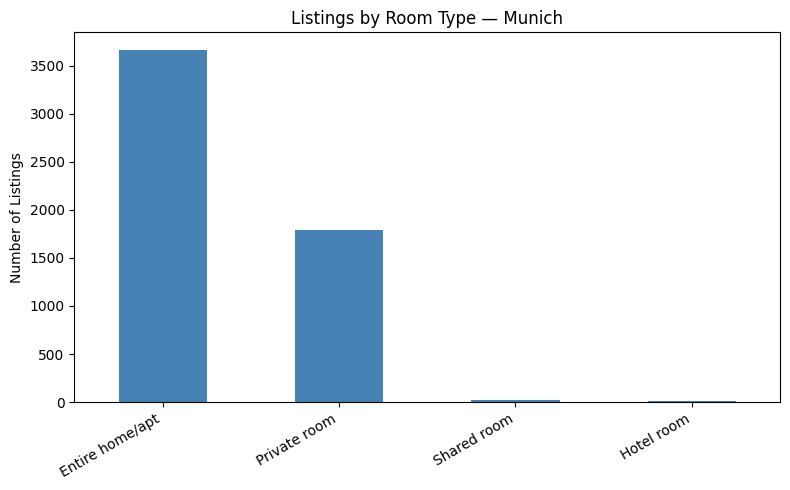

In [6]:
room_type = pd.read_sql("""
    SELECT
        room_type,
        COUNT(*)             AS total_listings,
        ROUND(AVG(price), 2) AS avg_price
    FROM listings
    GROUP BY room_type
    ORDER BY total_listings DESC
""", conn)

print(room_type.to_string(index=False))

room_type.plot(
    kind="bar",
    x="room_type",
    y="total_listings",
    figsize=(8, 5),
    legend=False,
    title="Listings by Room Type — Munich",
    color="steelblue"
)

plt.xlabel("")
plt.ylabel("Number of Listings")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("outputs/room_type_breakdown.png", dpi=150)
plt.show()

Host Segment Analysis

                host_segment  total_listings  avg_price  avg_rating
          1 listing (Casual)            3637     222.42        4.84
     2-3 listings (Semi-pro)             936     234.42        4.80
4-10 listings (Professional)             598     287.97        4.71
   10+ listings (Commercial)             316     348.00        4.61


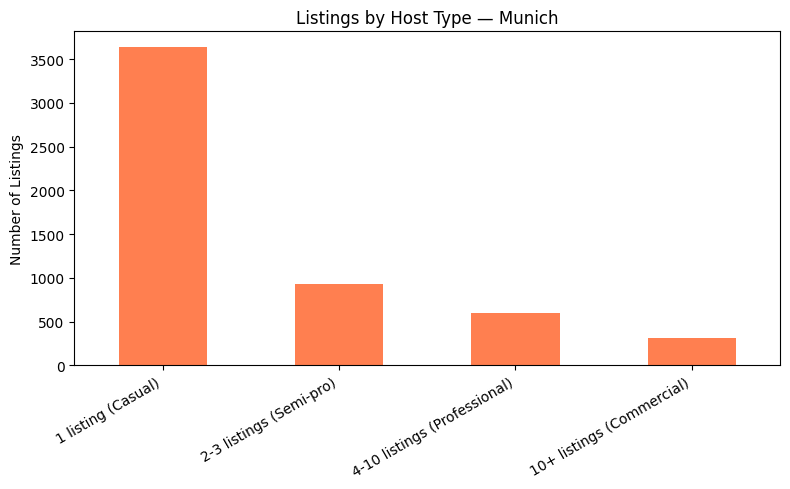

In [7]:
host_segment = pd.read_sql("""
    SELECT
        CASE
            WHEN calculated_host_listings_count = 1 THEN '1 listing (Casual)'
            WHEN calculated_host_listings_count <= 3 THEN '2-3 listings (Semi-pro)'
            WHEN calculated_host_listings_count <= 10 THEN '4-10 listings (Professional)'
            ELSE '10+ listings (Commercial)'
        END                          AS host_segment,
        COUNT(*)                     AS total_listings,
        ROUND(AVG(price), 2)         AS avg_price,
        ROUND(AVG(review_scores_rating), 2) AS avg_rating
    FROM listings
    GROUP BY host_segment
    ORDER BY total_listings DESC
""", conn)

print(host_segment.to_string(index=False))

host_segment.plot(
    kind="bar",
    x="host_segment",
    y="total_listings",
    figsize=(8, 5),
    legend=False,
    title="Listings by Host Type — Munich",
    color="coral"
)

plt.xlabel("")
plt.ylabel("Number of Listings")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("outputs/host_segmentation.png", dpi=150)
plt.show()

In [10]:
conn.close()

print("=" * 50)
print("  ANALYSIS COMPLETE!")
print("=" * 50)
print("\nCharts saved to outputs/:")
print("  ✅ avg_price_by_neighbourhood.png")
print("  ✅ room_type_breakdown.png")
print("  ✅ host_segmentation.png")
print("\nKey Findings:")
print("  - Most expensive neighbourhood: Altstadt-Lehel (€391/night)")
print("  - Cheapest neighbourhood: Aubing-Lochhausen-Langwied (€166/night)")
print("  - Average price across Munich: €239/night")
print("  - Average review score: 4.81/5")
print("  - Casual hosts dominate with 3,637 out of 5,487 listings")
print("  - Casual hosts get the best reviews with 4.84 vs 4.61 for commercial")
print("  - Commercial hosts charge the most @ €348/night average")
print("  - Entire home/Apartment are most listed making up 3663 and are the most expensive with an average price of €280.41")
print("  - Shared rooms are the least expensive with an average price of €109.45")
print("=" * 50)

  ANALYSIS COMPLETE!

Charts saved to outputs/:
  ✅ avg_price_by_neighbourhood.png
  ✅ room_type_breakdown.png
  ✅ host_segmentation.png

Key Findings:
  - Most expensive neighbourhood: Altstadt-Lehel (€391/night)
  - Cheapest neighbourhood: Aubing-Lochhausen-Langwied (€166/night)
  - Average price across Munich: €239/night
  - Average review score: 4.81/5
  - Casual hosts dominate with 3,637 out of 5,487 listings
  - Casual hosts get the best reviews with 4.84 vs 4.61 for commercial
  - Commercial hosts charge the most @ €348/night average
  - Entire home/Apartment are most listed making up 3663 and are the most expensive with an average price of €280.41
  - Shared rooms are the least expensive with an average price of €109.45
